# ARIMA'yı Ayrıştırma ile Birleştirmek

Basit bir ARIMA modeli sürecini zaten ele almıştık. Bu alıştırmada, derste gördüğünüz `seasonal decompose` aracıyla bir ARIMA modelinin kombinasyonunu kullanarak bu konuyu biraz daha geliştireceğiz. Mevsimsellikle __özel olarak__ başa çıkmak için kullanabileceğimiz modeller var, ancak burada adım adım ilerleyerek bu zaman serisini manuel olarak parçalayacağız, böylece onu tam olarak anlayacağız ve TS verileriyle çalışırken karşılaşabileceğimiz sorunları öğreneceğiz.

Bu challenge için günlük CO2 ppm ölçümleriyle çalışacağız, özellikle Mauna Loa Gözlemevi'nden alınan günlük CO2 ölçümleriyle 🌋

Bu ölçümler 1958'den beri alınıyor ve iklim biliminin temel taşlarından biri. Hawaii'de 3.000 metreden fazla yükseklikte konumlanmış olan gözlemevi, yerel emisyonlardan büyük ölçüde uzak olarak küresel atmosferik karbon seviyelerini izlemek için ideal bir konumdadır. Kayıtlar sağlam olmasına rağmen, __ara sıra enstrüman sorunları veya aşırı hava koşulları nedeniyle boşluklar içermektedir__, araştırmacılar bu kritik veri setinin bütünlüğünü korumak için analizlerinde bunları hesaba katmalıdır. 1974'ten beri __neredeyse__ günlük olarak alınan verilerin bir kısmını kullanacağız - notebook boyunca verilerdeki boşlukları ele alacağız!

Laboratuvarın yaptığı iklim çalışmaları hakkında merak ediyorsanız, buradan daha fazla bilgi edinebilirsiniz: https://gml.noaa.gov/ccgg/about/co2_measurements.html

## Veriyi Yükleme ve Keşfetme

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/co2_daily_mlo.csv")

In [3]:
df

,year,month,day,CO2 molfrac (ppm)
0,1974,5,17,333.38
1,1974,5,18,333.11
2,1974,5,19,333.46
3,1974,5,20,333.64
4,1974,5,21,333.50
...,...,...,...,...
15191,2023,10,19,419.44
15192,2023,10,20,419.53
15193,2023,10,21,418.90
15194,2023,10,23,419.09


Verilerin çalışmamız için pek güzel formatlanmadığını görebiliyoruz, bu yüzden önce `pd.to_datetime()` kullanarak bu adımı çözelim (bu fonksiyonu aynı anda birden fazla sütunda kullanabilirsiniz 👀). Daha fazla bilgi için [dokümanları](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) kontrol edin.

Doğru şekilde formatladıktan sonra, bunu index olarak ayarlayın.

In [5]:
import pandas as pd
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df.set_index('date', inplace=True)

CO2 değerlerinizi çizdirin ve partnerinizle ne gördüğünüzü tartışın. Verilerinizde herhangi bir boşluk var gibi görünüyor mu? __Emin misiniz__? DataFrame'inizin ilk 50 değerini kontrol edin

In [6]:
df.head(50)

,year,month,day,CO2 molfrac (ppm)
date,,,,
1974-05-17,1974,5,17,333.38
1974-05-18,1974,5,18,333.11
1974-05-19,1974,5,19,333.46
1974-05-20,1974,5,20,333.64
1974-05-21,1974,5,21,333.50
1974-05-22,1974,5,22,333.21
1974-05-23,1974,5,23,333.05
1974-05-26,1974,5,26,333.32
1974-05-27,1974,5,27,332.79


In [ ]:
# YOUR CODE HERE

Bazı tarihleri kaybetmişiz 😱 Açık `NaN` değerlerimiz olmasa da, index'imizde eksik tarihler var. Bu, TS verileriyle çalışırken __gerçekten__ dikkatli olmanız gereken bir şey.

Kaç gün eksik olduğumuzu hesaplayalım. Bitiş tarihinizi (`index`'inizin `max()`'ı) başlangıç tarihinizden (`index`'inizin `min()`'ı) çıkararak ikisi arasında kaç gün __olması gerektiğini__ görelim.

In [15]:
# Başlangıç ve bitiş tarihlerini alalım
start_date = df.index.min()
end_date = df.index.max()

# Toplam takvim gün sayısını hesaplayalım
total_days_expected = (end_date - start_date).days 

print(f"Olması gereken toplam gün sayısı: {total_days_expected}")

Olması gereken toplam gün sayısı: 18057


Bu, DataFrame'imizde __gerçekten__ sahip olduğumuz gün sayısından nasıl farklı? Cevabınızı `missing` değişkenine kaydedin

In [16]:
actual_days = df.index.nunique()
missing = total_days_expected - actual_days
print(f"Tekrar eden indeks sayısı: {df.index.duplicated().sum()}")
print(f"Elinizdeki mevcut satır sayısı: {actual_days}")
print(f"Kayıp gün sayısı: {missing}")

Tekrar eden indeks sayısı: 0
Elinizdeki mevcut satır sayısı: 15196
Kayıp gün sayısı: 2861


In [17]:
from nbresult import ChallengeResult

result = ChallengeResult('missing',
                         missing = missing)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_missing.py::TestMissing::test_missing PASSED                        [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/missing.pickle

git commit -m 'Completed missing step'

git push origin master



Eksik değerlerin gerçekte nerede olduğunu görelim. Sahip __olmamız gereken__ index'i oluşturmak için `pd.date_range` kullanın. Ardından DataFrame'in `.reindex()` fonksiyonunu bu yeni tarih aralığıyla kullanarak ilk 100 girişimizde null değerlerin gerçekte nerede olduğunu görün!

In [21]:
# Başlangıçtan bitişe her günü içeren seri
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
# Veriyi yeni takvime göre genişletiyoruz
df = df.reindex(full_index)

# İlk 100 satıra bakarak boşlukları (NaN) yakalayalım
print(df.head(100))

              year  month   day  CO2 molfrac (ppm)
1974-05-17  1974.0    5.0  17.0             333.38
1974-05-18  1974.0    5.0  18.0             333.11
1974-05-19  1974.0    5.0  19.0             333.46
1974-05-20  1974.0    5.0  20.0             333.64
1974-05-21  1974.0    5.0  21.0             333.50
...            ...    ...   ...                ...
1974-08-20  1974.0    8.0  20.0             329.07
1974-08-21  1974.0    8.0  21.0             329.41
1974-08-22     NaN    NaN   NaN                NaN
1974-08-23  1974.0    8.0  23.0             328.76
1974-08-24  1974.0    8.0  24.0             328.47

[100 rows x 4 columns]


Buradaki en basit seçenek, çok kullanışlı olan `pd.interpolate("linear")` fonksiyonunu kullanarak bunları bizim için doldurmak. Ne yaptığını görmek için aşağıdaki hücreyi çalıştırmayı deneyin:

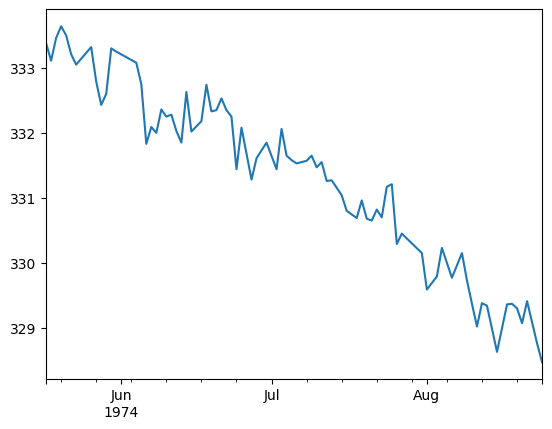

In [22]:
df["CO2 molfrac (ppm)"][:100].interpolate("linear").plot();

Interpolation bizim için noktaları bağlamak için basit bir doğrusal yöntem kullanır 😊 Tabii ki bu mükemmel olmayan bazı varsayımlar yapıyor ve aslında günlük örneklere ihtiyacımız yok - bunun yerine DataFrame'imizi aylık bazda `resample` edeceğiz ve bunu modellemeye çalışacağız. Her ayın ortalamasını içeren bir DataFrame oluşturmak için `.resample()` fonksiyonunu kullanmayı deneyin ve bunu `monthly` olarak adlandırın. [Dokümanları](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) burada görün.

In [25]:
# Veriyi aylık bazda resample edip ortalamasını alıyoruz
monthly = df[['CO2 molfrac (ppm)']].resample('ME').mean()
# İlk birkaç satıra bakarak yeni formatı görelim
print(monthly.head())

            CO2 molfrac (ppm)
1974-05-31         333.156923
1974-06-30         332.170400
1974-07-31         331.110000
1974-08-31         329.105769
1974-09-30         327.303182


In [26]:
print(monthly.isnull().sum())

CO2 molfrac (ppm)    1
dtype: int64


Eğer __hala__ kalan null değerleriniz varsa, bunları doldurmak için `interpolate` kullanabilirsiniz. Yeniden örneklenmiş verilerinizi çizdirin:

In [27]:
# Aylık verideki o tek boşluğu doğrusal yöntemle dolduruyoruz
monthly = monthly.interpolate(method='linear')

# Kontrol edelim, sonucun 0 çıkması lazım
print(monthly["CO2 molfrac (ppm)"].isnull().sum())

0


<Axes: >

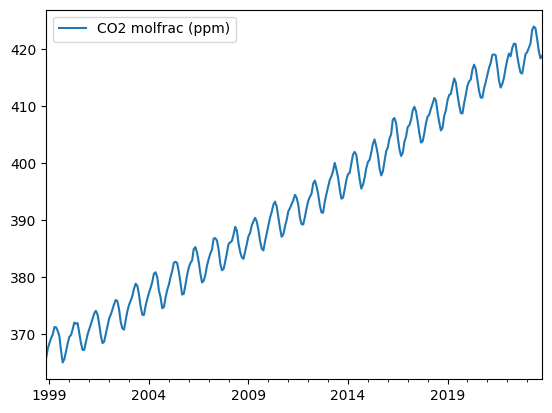

In [28]:
monthly[-300:].plot()

In [29]:
monthly["CO2 molfrac (ppm)"].iloc[0]

333.1569230769231

In [30]:
from nbresult import ChallengeResult

result = ChallengeResult('monthly',
                         monthly = monthly)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_monthly.py::TestMonthly::test_first_value PASSED                    [ 50%]
test_monthly.py::TestMonthly::test_missing PASSED                        [100%]

============================== 2 passed in 0.58s ===============================


💯 You can commit your code:

git add tests/monthly.pickle

git commit -m 'Completed monthly step'

git push origin master



## Eğitim Test Ayrımı

Şimdi eğitim ve test kümelerine ayırmamız gerekiyor (%80:%20 ayrımı yapacağız). Bunu yaparken dikkatli olun - kümelerimizin __sürekli__ olması gerekiyor!

In [31]:
# 1. Ayırım noktasını hesaplayalım
train_size = int(len(monthly) * 0.8)

# 2. Veriyi bu noktadan ikiye bölelim
train = monthly.iloc[:train_size]
test = monthly.iloc[train_size:]

print(f"Toplam veri: {len(monthly)}")
print(f"Eğitim kümesi boyutu: {len(train)}")
print(f"Test kümesi boyutu: {len(test)}")

Toplam veri: 594
Eğitim kümesi boyutu: 475
Test kümesi boyutu: 119


Veri hazırlığımız neredeyse bitti. Ancak ayrıştırma ve modellemeye başlamadan önce, modelimizin nasıl performans gösterdiğini görmek için bir baseline oluşturmalıyız.

Seçeceğimiz tipik baseline, bize mevcut olan son değeri tahmin etmektir. Bizim durumumuzda, bu sadece `train` DataFrame'imizdeki son noktadır.

`test` DataFrame'inizde `naive_preds` adında bir sütun oluşturun ve bunu `train`'deki son mevcut veri noktamıza eşit olarak ayarlayın


In [32]:
# 1. Eğitim kümesindeki en son (en güncel) CO2 değerini alalım
last_observation = train['CO2 molfrac (ppm)'].iloc[-1]

# 2. Test kümesinde 'naive_preds' sütunu oluşturup her satıra bu değeri atayalım
test = test.copy() # SettingWithCopy uyarısı almamak için kopya üzerinden ilerlemek güvenlidir
test['naive_preds'] = last_observation

# Kontrol edelim
print(test[['CO2 molfrac (ppm)', 'naive_preds']].head())

            CO2 molfrac (ppm)  naive_preds
2013-12-31         397.024000   395.360667
2014-01-31         398.043226   395.360667
2014-02-28         398.268889   395.360667
2014-03-31         399.895455   395.360667
2014-04-30         401.488889   395.360667


Bunu yaptıktan sonra, iki sütun arasındaki ortalama mutlak hatayı hesaplayın ve bunu `baseline_mae` olarak ayarlayın.

In [33]:
from sklearn.metrics import mean_absolute_error

# Gerçek değerler ile naive tahminlerimiz arasındaki hatayı hesaplayalım
baseline_mae = mean_absolute_error(test['CO2 molfrac (ppm)'], test['naive_preds'])

print(f"Baseline MAE: {baseline_mae:.4f} ppm")

Baseline MAE: 14.5038 ppm


In [34]:
from nbresult import ChallengeResult

result = ChallengeResult('baseline',
                         test = test,
                         baseline_mae = baseline_mae)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 3 items

test_baseline.py::TestBaseline::test_baseline_mae PASSED                 [ 33%]
test_baseline.py::TestBaseline::test_first_value PASSED                  [ 66%]
test_baseline.py::TestBaseline::test_missing PASSED                      [100%]

=============================== warnings summary ===============================
test_baseline.py::TestBaseline::test_first_value
  /Users/aybukealtuntas/S17D4-S-arima-seasonal/tests/test_baseline.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame 

## Modellemeye Hazırlanmak

Bazı Zaman Serisi modelleriyle, verilerimizi modele atabilir ve onun bizim için ayrıştırmasını, durağan hale getirmesini ve sonra modellemesini umabiliriz (SARIMAX veya TBATS bunun iyi örnekleridir), ancak bunun yerine adım adım ilerleyeceğiz. Mevsimsellik ve trendi bizim için kaldıracak bir modele güvenmediğimiz için, bunları kendimiz halledeceğiz.

Derste gördüğünüz `seasonal_decompose` aracını import edin ve Zaman Serinizde her iki yöntemi de deneyin (hem "multiplicative" hem "additive").

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

In [37]:
result_add = seasonal_decompose(train['CO2 molfrac (ppm)'], model='additive', period=12)

In [38]:
result_mul = seasonal_decompose(train['CO2 molfrac (ppm)'], model='multiplicative', period=12)

Her ikisinden de residualleri (`.resid` attribute'una erişin) çizdirin ve unutmayın - zamandan mümkün olduğunce __etkilenmemiş__ görünen olanı istiyoruz

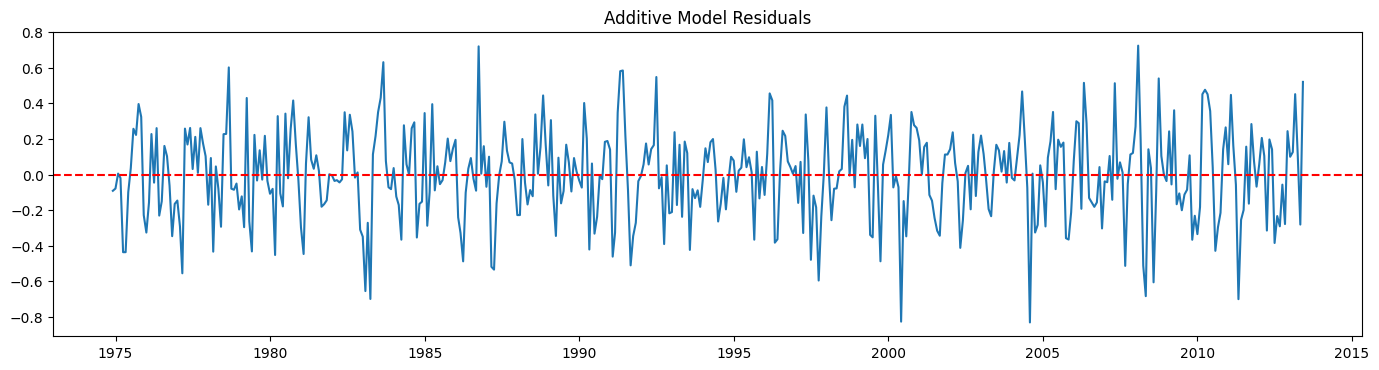

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Additive Residuals
plt.subplot(2, 1, 1)
plt.plot(result_add.resid)
plt.title('Additive Model Residuals')
plt.axhline(0, color='red', linestyle='--') # Sıfır çizgisi referans için



plt.tight_layout()
plt.show()

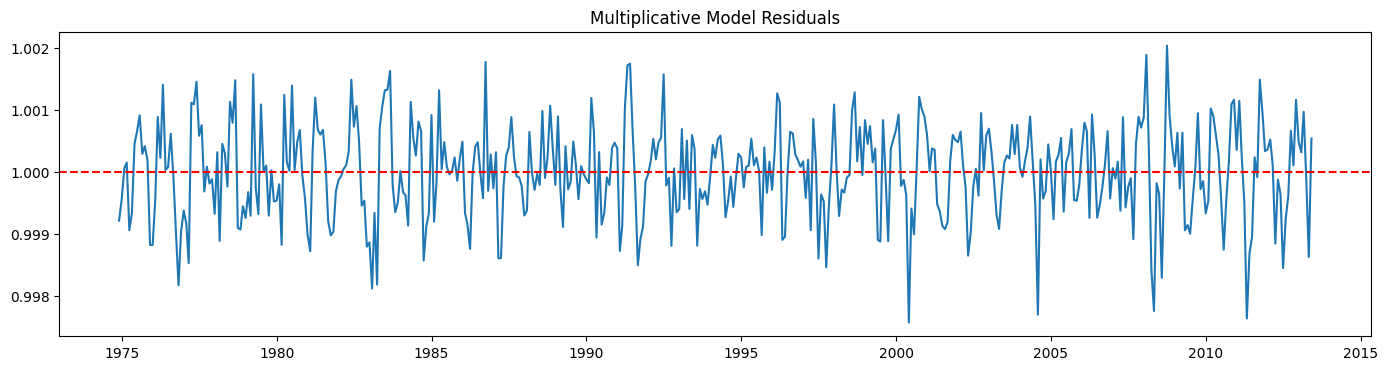

In [40]:
plt.figure(figsize=(14, 7))

# Multiplicative Residuals
plt.subplot(2, 1, 2)
plt.plot(result_mul.resid)
plt.title('Multiplicative Model Residuals')
plt.axhline(1, color='red', linestyle='--') # Çarpımsal modelde merkez 1'dir

plt.tight_layout()
plt.show()

Her ikisi de makul ölçüde durağan göründüğü için, multiplicative modeli seçeceğiz.

Şimdi stratejimiz zaman serimizin mevsimsel bileşenini çıkarmak.

Bunu nasıl yapabiliriz? 🤔


İlk olarak, `train` DataFrame'inizde zaman serinizin `.seasonal` bileşeniyle doldurulmuş `"seasonal_component"` adında bir sütun oluşturun.

Bunu yaptıktan sonra, sadece mevsimsel bileşenlerinizin __bir yılını__ içeren (yani `seasonal components` sütununuzun ilk 12 satırı) ayrı, daha küçük bir DataFrame oluşturun. Bu daha sonra bizim için yararlı olacak. Bunu `seasonal_one_year` olarak adlandırın ve karşılık gelen `index.month`'a eşit bir `"month"` sütununuz olduğundan emin olun (örneğin, Ocak mevsimsel bileşenine sahip bir satırınız ve yanında 1 olsun).

<img src = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/09-Time-Series/seasonal_component_one.png">

In [41]:
# Ayrıştırma sonucundaki mevsimsel bileşeni 'seasonal_component' sütununa atıyoruz
train = train.copy()
train["seasonal_component"] = result_mul.seasonal

print(train[["CO2 molfrac (ppm)", "seasonal_component"]].head())

# İlk 12 satırı alarak bir yıllık döngüyü izole ediyoruz
seasonal_one_year = train[["seasonal_component"]].iloc[:12].copy()

# Ay bilgilerini (1'den 12'ye kadar) sütun olarak ekliyoruz
seasonal_one_year["month"] = seasonal_one_year.index.month

print(seasonal_one_year)

            CO2 molfrac (ppm)  seasonal_component
1974-05-31         333.156923            1.008482
1974-06-30         332.170400            1.006564
1974-07-31         331.110000            1.001811
1974-08-31         329.105769            0.995762
1974-09-30         327.303182            0.990900
            seasonal_component  month
1974-05-31            1.008482      5
1974-06-30            1.006564      6
1974-07-31            1.001811      7
1974-08-31            0.995762      8
1974-09-30            0.990900      9
1974-10-31            0.990801     10
1974-11-30            0.994131     11
1974-12-31            0.997567     12
1975-01-31            1.000244      1
1975-02-28            1.002097      2
1975-03-31            1.004264      3
1975-04-30            1.007375      4


Bu multiplicative bir modelden geldiği için, bu mevsimsel bileşeni __kaldırmak__ istiyorsak, orijinal zaman serimizi bu tekrarlanan (12 aylık döngü) değerlere __bölmemiz__ gerekecek.

In [42]:
from nbresult import ChallengeResult

result = ChallengeResult('seasonal',
                         train = train,
                         seasonal = seasonal_one_year)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_seasonal.py::TestSeasonal::test_seasonal_column PASSED              [ 50%]
test_seasonal.py::TestSeasonal::test_seasonal_year_shape PASSED          [100%]

============================== 2 passed in 0.59s ===============================


💯 You can commit your code:

git add tests/seasonal.pickle

git commit -m 'Completed seasonal step'

git push origin master



Orijinal zaman serinizin değerini mevsimsel bileşene bölen `"seasonal_stripped"` adında yeni bir sütun oluşturun.

In [43]:
# Orijinal CO2 değerlerini mevsimsel bileşene bölerek arındırıyoruz
train["seasonal_stripped"] = train["CO2 molfrac (ppm)"] / train["seasonal_component"]

# İlk birkaç satıra bakarak değişimi görelim
print(train[["CO2 molfrac (ppm)", "seasonal_component", "seasonal_stripped"]].head())

            CO2 molfrac (ppm)  seasonal_component  seasonal_stripped
1974-05-31         333.156923            1.008482         330.354959
1974-06-30         332.170400            1.006564         330.004173
1974-07-31         331.110000            1.001811         330.511417
1974-08-31         329.105769            0.995762         330.506354
1974-09-30         327.303182            0.990900         330.308904


Bu yeni sütunu çizdirin:

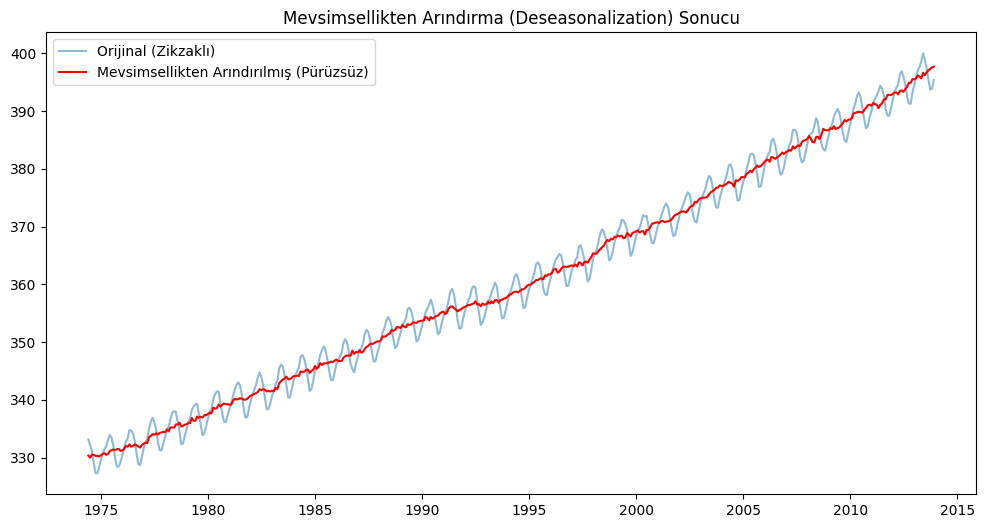

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train.index, train["CO2 molfrac (ppm)"], label="Orijinal (Zikzaklı)", alpha=0.5)
plt.plot(train.index, train["seasonal_stripped"], label="Mevsimsellikten Arındırılmış (Pürüzsüz)", color="red")
plt.title("Mevsimsellikten Arındırma (Deseasonalization) Sonucu")
plt.legend()
plt.show()

Henuz durağan görünüyor mu? Günün arkadaşınızla neden öyle olduğunu veya olmadığını tartışın.

Bir sonraki görevimiz bu __mevsimsellikten arındırılmış__ zaman serisini alıp durağan hale getirmek. `.diff()` kullanmayı deneyin ve nasıl göründüğüne bakın. Sonra herhangi bir değişiklik görmek için bir kez daha diff yapmayı deneyin.

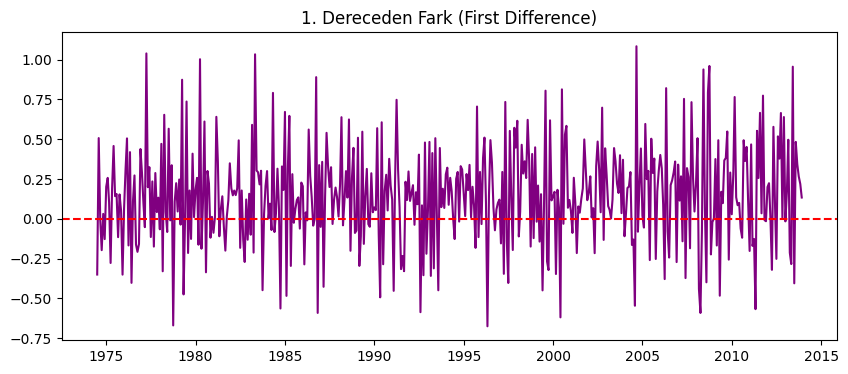

In [45]:
# 1. Fark: Trendi öldürme girişimi
train["diff_1"] = train["seasonal_stripped"].diff()

plt.figure(figsize=(10, 4))
plt.plot(train["diff_1"], color="purple")
plt.title("1. Dereceden Fark (First Difference)")
plt.axhline(0, color='red', linestyle='--')
plt.show()

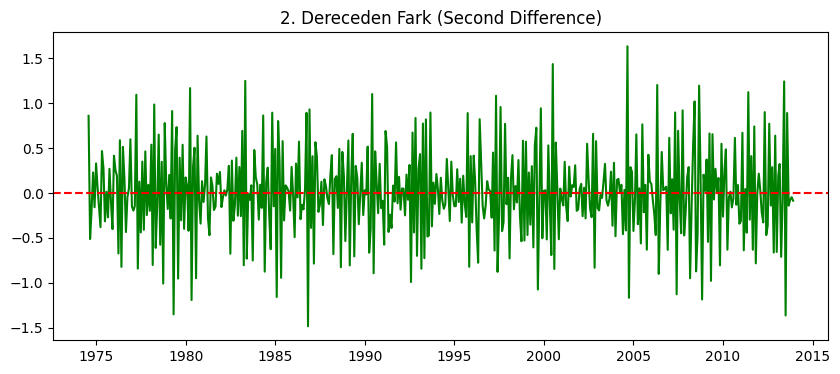

In [46]:
# 2. Fark: Kalan trend kırıntılarını temizleme
train["diff_2"] = train["seasonal_stripped"].diff().diff()

plt.figure(figsize=(10, 4))
plt.plot(train["diff_2"], color="green")
plt.title("2. Dereceden Fark (Second Difference)")
plt.axhline(0, color='red', linestyle='--')
plt.show()

Her ikisi de görsel olarak oldukça durağan görünmeli, her birinin durağan olduğunu doğrulamak için derste gördüğünüz `adfuller` (Augmented Dicky-Fuller) testini kullanın.

Not: `diff` yaptığınızda DataFrame'inizde null değerler oluşturursunuz, ADF testi yapmak için bunları düşürmeniz gerekir.

In [48]:
from statsmodels.tsa.stattools import adfuller

In [49]:
# 1. Fark için ADF Testi
# train["diff_1"] = train["seasonal_stripped"].diff()
res_diff1 = adfuller(train["diff_1"].dropna())

print(f"1. Fark ADF p-değeri: {res_diff1[1]:.10f}")

1. Fark ADF p-değeri: 0.0000048164


In [50]:
# 2. Fark için ADF Testi
# train["diff_2"] = train["seasonal_stripped"].diff().diff()
res_diff2 = adfuller(train["diff_2"].dropna())


print(f"2. Fark ADF p-değeri: {res_diff2[1]:.10f}")

2. Fark ADF p-değeri: 0.0000000000


Her ikisi de makul ölçüde durağan görünüyor ve aşırı differencing'e gerek yok gibi görünüyor (yine de daha sonra iki kez diff yapılmış bir zaman serisi oluşturmayı her zaman deneyebiliriz). Hadi `acf` ve `pacf` grafiklerimizi çizmeye devam edelim (herhangi bir `null` değeri düşürdüğünüzden emin olun - bunlar ACF ve PACF hesaplayıcılarınızı bozar) 😔

In [51]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

<Figure size 1200x600 with 0 Axes>

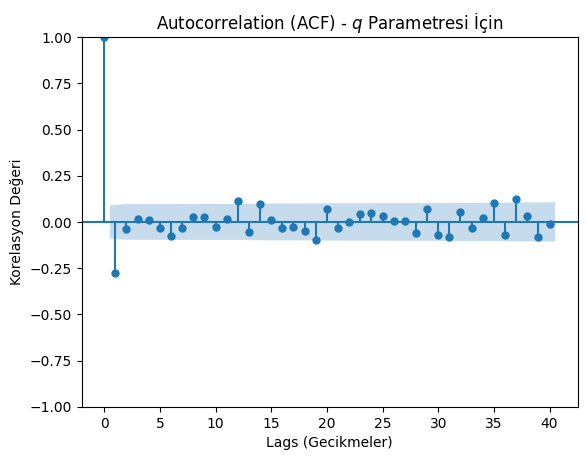

In [52]:
# NaN değerleri temizlenmiş birinci fark serisini kullanalım
diff_data = train["diff_1"].dropna()

# Sadece ACF
plt.figure(figsize=(12, 6))
plot_acf(train["diff_1"].dropna(), lags=40)
plt.title('Autocorrelation (ACF) - $q$ Parametresi İçin')
plt.xlabel('Lags (Gecikmeler)')
plt.ylabel('Korelasyon Değeri')
plt.show()

<Figure size 1200x600 with 0 Axes>

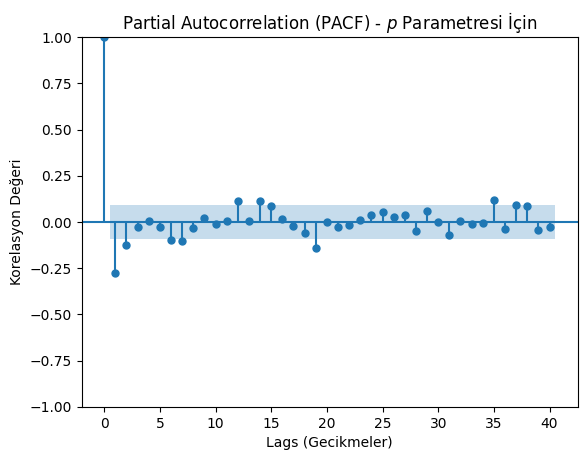

In [54]:

plt.figure(figsize=(12, 6))
plot_pacf(train["diff_1"].dropna(), lags=40, method='yw')
plt.title('Partial Autocorrelation (PACF) - $p$ Parametresi İçin')
plt.xlabel('Lags (Gecikmeler)')
plt.ylabel('Korelasyon Değeri')
plt.show()

Bu grafiklerin gerçekte ne anlama geldiğini arkadaşınızla konuşmak için zaman ayırın. Hangisi sizin `p` parametrenize karşılık geliyor ve hangisi `q` parametrenize?

Şimdi `p` `d` ve `q` değerleriniz için uygun order değerleriyle basit bir ARIMA modeli oluşturun. Model özetini inceleyin.

In [64]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")
# Modeli kuruyoruz (p, d, q)
# Veri olarak mevsimsellikten arındırılmış 'seasonal_stripped' kullanıyoruz
model = ARIMA(train["seasonal_stripped"], order=(2, 1, 1))
model_fit = model.fit()

# Özet tabloyu yazdırıyoruz
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      seasonal_stripped   No. Observations:                  475
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -107.921
Date:                Mon, 16 Mar 2026   AIC                            223.842
Time:                        00:35:13   BIC                            240.487
Sample:                    05-31-1974   HQIC                           230.388
                         - 11-30-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7212      0.043     16.934      0.000       0.638       0.805
ar.L2          0.2787      0.043      6.540      0.000       0.195       0.362
ma.L1         -0.9922      0.010    -94.719      0.0

Özet hakkında ne fark ediyorsunuz? Buradaki en önemli özellikler neler?

Katsayılarımıza güvenebiliriz gibi görünüyor ve ~223'lük bir AIC'miz var. Ama bu en iyi model miydi? Farklı modelleri grid search yapmak ve hangisinin en iyi AIC'ye sahip olduğunu görmek için `auto_arima` fonksiyonunu kullanmayı deneyin

In [61]:
train

,CO2 molfrac (ppm),seasonal_component,seasonal_stripped,diff_1,diff_2
1974-05-31,333.156923,1.008482,330.354959,NaN,NaN
1974-06-30,332.170400,1.006564,330.004173,-0.350786,NaN
1974-07-31,331.110000,1.001811,330.511417,0.507244,0.858030
1974-08-31,329.105769,0.995762,330.506354,-0.005063,-0.512307
1974-09-30,327.303182,0.990900,330.308904,-0.197450,-0.192386
...,...,...,...,...,...
2013-07-31,397.451905,1.001811,396.733388,0.483315,0.889291
2013-08-31,395.393704,0.995762,397.076392,0.343003,-0.140312
2013-09-30,393.726538,0.990900,397.342246,0.265855,-0.077149
2013-10-31,393.904286,0.990801,397.561262,0.219015,-0.046839


In [63]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")
# auto_arima'yı mevsimsellikten arındırılmış verimiz üzerinde çalıştırıyoruz
# seasonal=False diyoruz çünkü mevsimselliği zaten manuel çıkardık
stepwise_fit = auto_arima(train["seasonal_stripped"], 
                          start_p=0, start_q=0,
                          max_p=5, max_q=5, # Geniş bir aralıkta ara
                          d=1,              # d=1 olduğunu zaten bulmuştuk
                          seasonal=False, 
                          stepwise=True,    # Daha hızlı arama yapması için
                          trace=True)       # Tüm denemeleri bize göster

print(stepwise_fit.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=252.307, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=216.874, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=209.862, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=338.365, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=211.246, Time=0.18 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=211.280, Time=0.09 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=213.283, Time=0.25 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=339.127, Time=0.03 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 0.767 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  475
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -101.931
Date:                Mon, 16 Mar 2026   AIC                            209.862
Time:                        00:35:08   BIC 

En iyi AIC skorunuzu `best_AIC`'ye kaydedin

In [65]:
best_AIC = stepwise_fit.aic()

print(f"En iyi modelin AIC skoru: {best_AIC:.3f}")

En iyi modelin AIC skoru: 209.862


In [66]:
from nbresult import ChallengeResult

result = ChallengeResult('score',
                         aic_score = best_AIC)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_score.py::TestScore::test_AIC_score PASSED                          [100%]

============================== 1 passed in 0.21s ===============================


💯 You can commit your code:

git add tests/score.pickle

git commit -m 'Completed score step'

git push origin master



Çoğu zaman, hangi modelin verilerimize en iyi uyacağını tahmin etmek zor olabilir, bu yüzden genellikle grid-search yapmak ve modellerimizin AIC skorlarını karşılaştırmak iyi bir fikirdir 🧐 Burada, bir __(0,1,1)__ modelinin daha iyi bir AIC skoru aldığı görünüyor (yani orijinal modelimizin MA bileşenleri muhtemelen model likelihood'ımızı o kadar iyileştirmiyordu!)

### Tahminler Yapmak (biraz Pandas çalışmasına hazır olun!)

Artik en iyi modelimize sahip olduğumuza göre, bazı tahminler ve - önemlisi - bazı güven aralıkları oluşturmak istiyoruz. Test setinizin uzunluğu için tahmin yapmak üzere modelinizi kullanın ve bu aralıkları da döndürdüğünüzden emin olun (`return_conf_int = True` kullanın). `preds`, `upper` ve `lower` sınırları için sütunlar içeren bir `preds_df` DataFrame oluşturun.

In [67]:
import pandas as pd

# 1. Test setinin uzunluğu kadar tahmin ve güven aralıklarını alıyoruz
# return_conf_int=True bize iki ayrı çıktı verir: tahminler ve aralık matrisi
n_periods = len(test)
preds, conf_int = stepwise_fit.predict(n_periods=n_periods, return_conf_int=True)

In [68]:
# 2. preds_df DataFrame'ini oluşturuyoruz
preds_df = pd.DataFrame({
    'preds': preds,
    'lower': conf_int[:, 0],
    'upper': conf_int[:, 1]
}, index=test.index) # Test setinin zaman damgalarını (index) kullanıyoruz

In [69]:
print(preds_df.head())

                 preds       lower       upper
2013-12-31  397.824555  397.236599  398.412512
2014-01-31  397.966868  397.257358  398.676377
2014-02-28  398.109180  397.296090  398.922270
2014-03-31  398.251492  397.346602  399.156383
2014-04-30  398.393805  397.405605  399.382004


In [70]:
from nbresult import ChallengeResult

result = ChallengeResult('preds',
                         preds_df = preds_df)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_preds.py::TestPreds::test_df_values PASSED                          [ 50%]
test_preds.py::TestPreds::test_preds_cols PASSED                         [100%]

============================== 2 passed in 0.68s ===============================


💯 You can commit your code:

git add tests/preds.pickle

git commit -m 'Completed preds step'

git push origin master



Şimdi bunları çizdirin ve `train` verilerinizle karşılaştırıldığında nasıl göründüklerine bakın

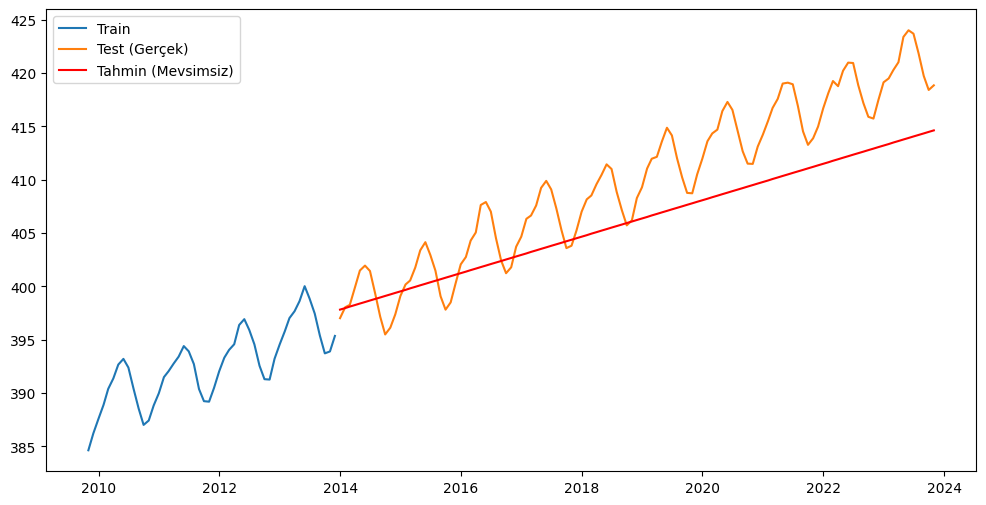

In [71]:
# Mevsimsellik eklenmemiş ham tahminleri çizdirme
plt.figure(figsize=(12, 6))
plt.plot(train.index[-50:], train["CO2 molfrac (ppm)"].iloc[-50:], label="Train")
plt.plot(test.index, test["CO2 molfrac (ppm)"], label="Test (Gerçek)")
plt.plot(preds_df.index, preds_df["preds"], label="Tahmin (Mevsimsiz)", color="red")
plt.legend()
plt.show()

Bir şeyler biraz yanlış görünüyor, değil mi? Açıkça mevsimsellik olan bir şeyden çıkan üç düz çizgiye bakıyoruz. Bunu hesaba katmak için, daha önce çıkardığımız mevsimsellik bileşenini yeniden dahil etmemiz gerekiyor!

`preds_df` DataFrame'inizde bir `month` sütunu oluşturun ve bunu index'in ay bileşeniyle doldurun.

In [73]:
# İndeksteki tarih bilgisinden ay numarasını çekiyoruz
preds_df['month'] = preds_df.index.month

Artık daha önce oluşturduğumuz `seasonal_one_year` DataFrame'ini alıp `preds_df`'imize basitçe merge edebiliriz!

In [74]:
# seasonal_one_year DataFrame'ini preds_df ile 'month' sütunu üzerinden birleştiriyoruz
preds_df = preds_df.reset_index().merge(seasonal_one_year, on='month').set_index('index')

# İndeksi tekrar sıralayalım (merge işlemi sırayı bozabilir)
preds_df = preds_df.sort_index()

In [75]:
# Mevsimselliği tahminlere ve güven aralıklarına uyguluyoruz
preds_df['final_preds'] = preds_df['preds'] * preds_df['seasonal_component']
preds_df['final_lower'] = preds_df['lower'] * preds_df['seasonal_component']
preds_df['final_upper'] = preds_df['upper'] * preds_df['seasonal_component']

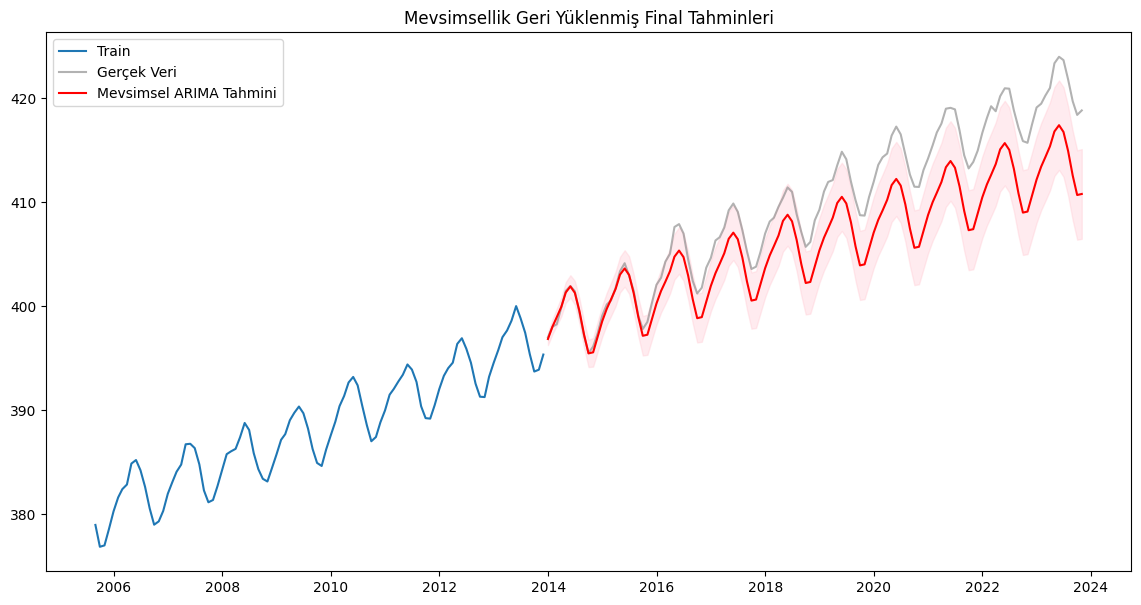

In [76]:
plt.figure(figsize=(14, 7))
plt.plot(train.index[-100:], train["CO2 molfrac (ppm)"].iloc[-100:], label="Train")
plt.plot(test.index, test["CO2 molfrac (ppm)"], label="Gerçek Veri", color="gray", alpha=0.6)
plt.plot(preds_df.index, preds_df["final_preds"], label="Mevsimsel ARIMA Tahmini", color="red")

# Güven aralığını da ekleyelim
plt.fill_between(preds_df.index, preds_df["final_lower"], preds_df["final_upper"], color='pink', alpha=0.3)

plt.legend()
plt.title("Mevsimsellik Geri Yüklenmiş Final Tahminleri")
plt.show()

In [ ]:
preds_df

Şimdi `preds_df` DataFrame'inde yeni sütunlar olarak `full_preds`, `upper_conf` ve `lower_conf`'ı (`preds`, `upper` __ve__ `lower` sütunlarınızı `preds_df` DataFrame'imizde artık sahip olduğumuz mevsimsel bileşenle çarparak) oluşturabilirsiniz.

In [77]:
# Mevsimsel bileşeni (seasonal_component) kullanarak nihai tahminleri ve güven aralıklarını hesaplıyoruz
preds_df['full_preds'] = preds_df['preds'] * preds_df['seasonal_component']
preds_df['upper_conf'] = preds_df['upper'] * preds_df['seasonal_component']
preds_df['lower_conf'] = preds_df['lower'] * preds_df['seasonal_component']

# Sonucu kontrol etmek için ilk birkaç satıra bakalım
print(preds_df[['full_preds', 'upper_conf', 'lower_conf']].head())

            full_preds  upper_conf  lower_conf
index                                         
2013-12-31  396.856692  397.443218  396.270166
2014-01-31  398.064148  398.773832  397.354465
2014-02-28  398.944099  399.758894  398.129304
2014-03-31  399.949716  400.858465  399.040966
2014-04-30  401.331956  402.327444  400.336469


Son olarak, plotting'i bizim için kolaylaştırmak için, `preds_df`'nizin index'ini `test` DataFrame'inizin index'iyle aynı olacak şekilde ayarlayın (aynı uzunluğa sahip oldukları için bu bizim için oldukça kolay olmalı!)

In [78]:
# preds_df'nin indeksini test setinin indeksiyle (tarih damgalarıyla) tam olarak eşitleyelim
preds_df.index = test.index

# Her şeyin yolunda olduğunu doğrulamak için kontrol edelim
print(f"Test indeksi tipi: {type(test.index)}")
print(f"Preds indeksi tipi: {type(preds_df.index)}")
preds_df.head()

Test indeksi tipi: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Preds indeksi tipi: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


,preds,lower,upper,month,seasonal_component,final_preds,final_lower,final_upper,full_preds,upper_conf,lower_conf
2013-12-31,397.824555,397.236599,398.412512,12,0.997567,396.856692,396.270166,397.443218,396.856692,397.443218,396.270166
2014-01-31,397.966868,397.257358,398.676377,1,1.000244,398.064148,397.354465,398.773832,398.064148,398.773832,397.354465
2014-02-28,398.109180,397.296090,398.922270,2,1.002097,398.944099,398.129304,399.758894,398.944099,399.758894,398.129304
2014-03-31,398.251492,397.346602,399.156383,3,1.004264,399.949716,399.040966,400.858465,399.949716,400.858465,399.040966
2014-04-30,398.393805,397.405605,399.382004,4,1.007375,401.331956,400.336469,402.327444,401.331956,402.327444,400.336469


In [79]:
from nbresult import ChallengeResult

result = ChallengeResult('fullpreds',
                         preds_df = preds_df)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/aybukealtuntas/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/aybukealtuntas/S17D4-S-arima-seasonal/tests
plugins: dash-4.0.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_fullpreds.py::TestFullpreds::test_columns PASSED                    [ 50%]
test_fullpreds.py::TestFullpreds::test_index PASSED                      [100%]

============================== 2 passed in 0.62s ===============================


💯 You can commit your code:

git add tests/fullpreds.pickle

git commit -m 'Completed fullpreds step'

git push origin master



Şimdi her şeyi çizdirin - train'inizin sonu (örneğin son 100 değer), tam tahminleriniz, üst ve alt güven sınırları ve `preds_df` DataFrame'inizden gerçek değerler __ve__ baseline'nız!

Not: 'baseline' sütunu bulunamadığı için çizilmedi.


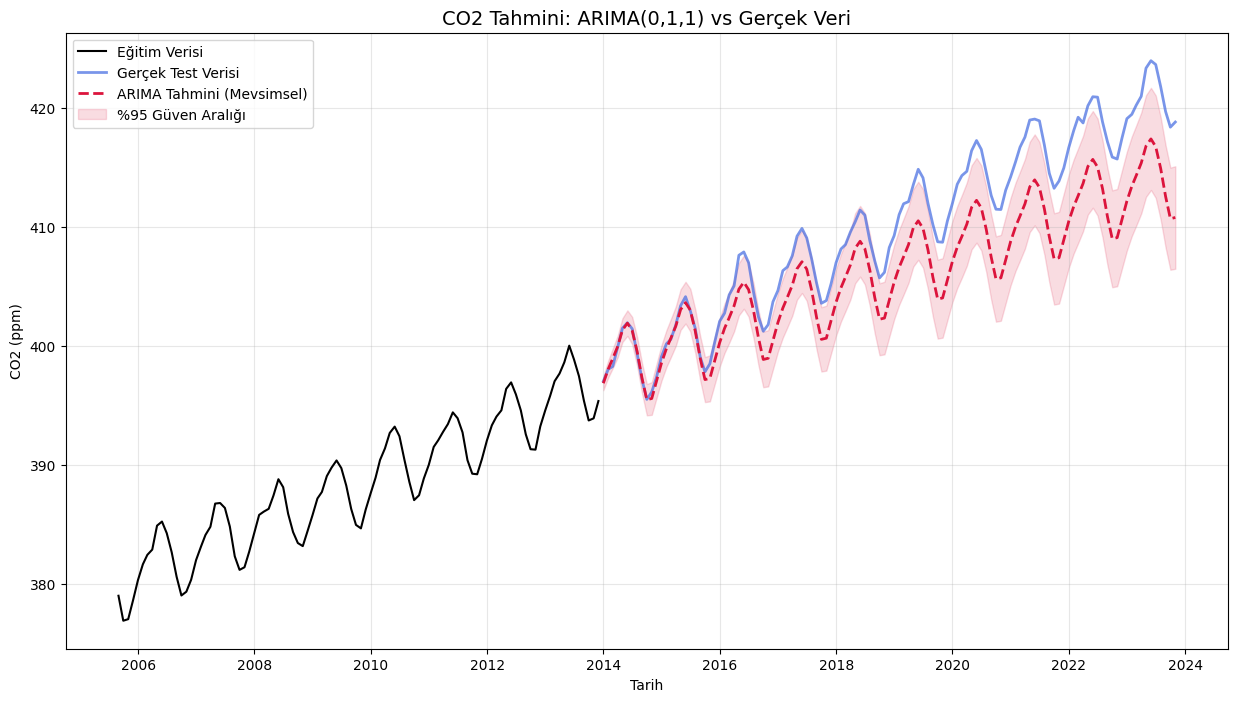

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

# 1. Eğitim verisi (Son 100)
plt.plot(train.index[-100:], train["CO2 molfrac (ppm)"].iloc[-100:], 
         label="Eğitim Verisi", color="black", linewidth=1.5)

# 2. Gerçek Test Verisi
plt.plot(test.index, test["CO2 molfrac (ppm)"], 
         label="Gerçek Test Verisi", color="royalblue", alpha=0.7, linewidth=2)

# 3. ARIMA Tahminleri (full_preds)
plt.plot(preds_df.index, preds_df["full_preds"], 
         label="ARIMA Tahmini (Mevsimsel)", color="crimson", linestyle="--", linewidth=2)

# 4. Güven Aralıkları
plt.fill_between(preds_df.index, preds_df["lower_conf"], preds_df["upper_conf"], 
                 color='crimson', alpha=0.15, label="%95 Güven Aralığı")

# 5. Baseline Kontrolü (Hata almamak için)
if 'baseline' in test.columns:
    plt.plot(test.index, test["baseline"], label="Baseline", color="orange", linestyle=":", alpha=0.8)
else:
    print("Not: 'baseline' sütunu bulunamadığı için çizilmedi.")

plt.title("CO2 Tahmini: ARIMA(0,1,1) vs Gerçek Veri", fontsize=14)
plt.xlabel("Tarih")
plt.ylabel("CO2 (ppm)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

Tahminlerimiz oldukça iyi görünüyor! Gerçek değerlerin tahmin ettiklerimizden biraz daha yüksek olduğunu görebiliyoruz ancak tahmin yapmaya başladığımız zamandan tam 10 yıl sonrası için güven aralıklarımızın sınırları içinde iyi bir şekilde kalıyor.

Neden değerlerimiz gerçek değerlerin altına düştü? Test verisini ayrıştırmak ve trend bileşenine bakmak için aşağıdaki hücreyi çalıştırın 👀


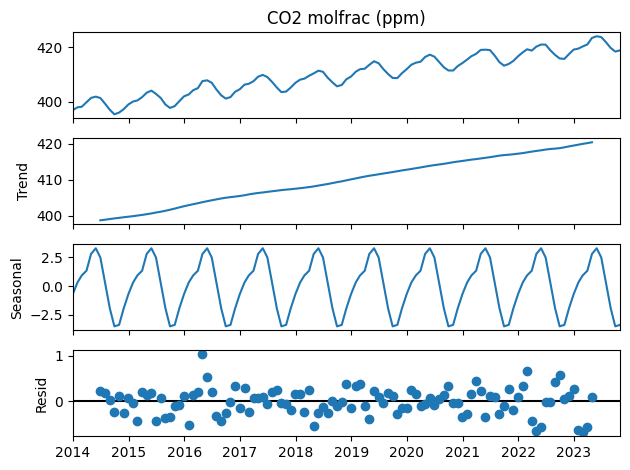

In [82]:
seasonal_decompose(test["CO2 molfrac (ppm)"]).plot();

2016-2018'de normal (biraz daha sığ) trend tekrar devralınmadan önce tüm değerlerimizde __hafif bir artis__ olduğu görünüyor. Bu, test veri setimizde basitçe tahmin edemeyeceğimiz bir şeyin meydana gelmesinin harika bir örneği. CO2 okumalarında neden bir artış olduğunu bilmiyoruz - ve bunun için tahmin yapamadık.

❗ Zaman Serisi ile modelleme yaptığımızda, __sihirli bir şekilde geleceği tahmin edemeyiz__. Yapmaya çalıştığımız şey, geçmişin desenlerini doğru bir şekilde yakalamak ve sonra bunları genişletmektir.

- Çoğu zaman, ham tahminleriniz (mevsimsel bileşen olmadan) oldukça sıkıcı düz bir çizgi gibi görünecektir 🙄 (mevcut başlangıç tahminlerimizin yaptığı gibi) ancak bu beklediğimiz bir şey
- Zaman Serisi analizi yaparken elde ettiğimiz değerin çoğu, trendlerimizi, mevsimsel bileşenlerimizi ve güven aralıklarımızı __nicelleştirebilmemizde__ yatıyor, böylece iyi bilgilendirilmiş kararlar verebiliriz ✅

Son olarak, modelimizin baseline'ımızdan ne kadar daha iyi olduğunu hızlıca nicelleyelim. `preds`'leriniz (mevsimsel bileşenleriyle birlikte) ve gerçek değerler arasındaki ortalama mutlak hatayı hesaplayın. `model_mae`'nizin orijinal `baseline_mae`'den düşük olup olmadığına bakın.

In [85]:
# Hataların mutlak değerini (.abs()) alarak ortalamasını hesaplıyoruz
model_mae = (test["CO2 molfrac (ppm)"] - preds_df["full_preds"]).abs().mean()

print(f"Modelin Gerçek MAE Değeri: {model_mae:.4f}")

Modelin Gerçek MAE Değeri: 3.6449


Final MAE'miz orijinal baseline'ımızdan __çok__ daha iyi olmalı. Harika iş 🥳 